Columns: Index(['Age (years)', 'Gender', 'BMI (kg/m^2)', 'Blood_Pressure (mmHg)',
       'Cholesterol (mg/dL)', 'Glucose (mg/dL)', 'Heart_Rate (bpm)', 'Smoking',
       'Alcohol_Intake (units/week)', 'Physical_Activity (hours/week)',
       'Family_History', 'Disease_Risk'],
      dtype='str')
  Age (years)  Gender  BMI (kg/m^2) Blood_Pressure (mmHg)  \
0          34    male          27.9                94/119   
1          72  Female          25.7               163/109   
2          29  Others           NaN               161/108   
3          18  female          27.9               115/112   
4          34    male          25.5               169/117   

   Cholesterol (mg/dL)  Glucose (mg/dL)  Heart_Rate (bpm) Smoking  \
0                277.0            104.0             111.0     NaN   
1                264.0            122.0              81.0     NaN   
2                248.0            103.0              90.0      no   
3                191.0            127.0              64.0     

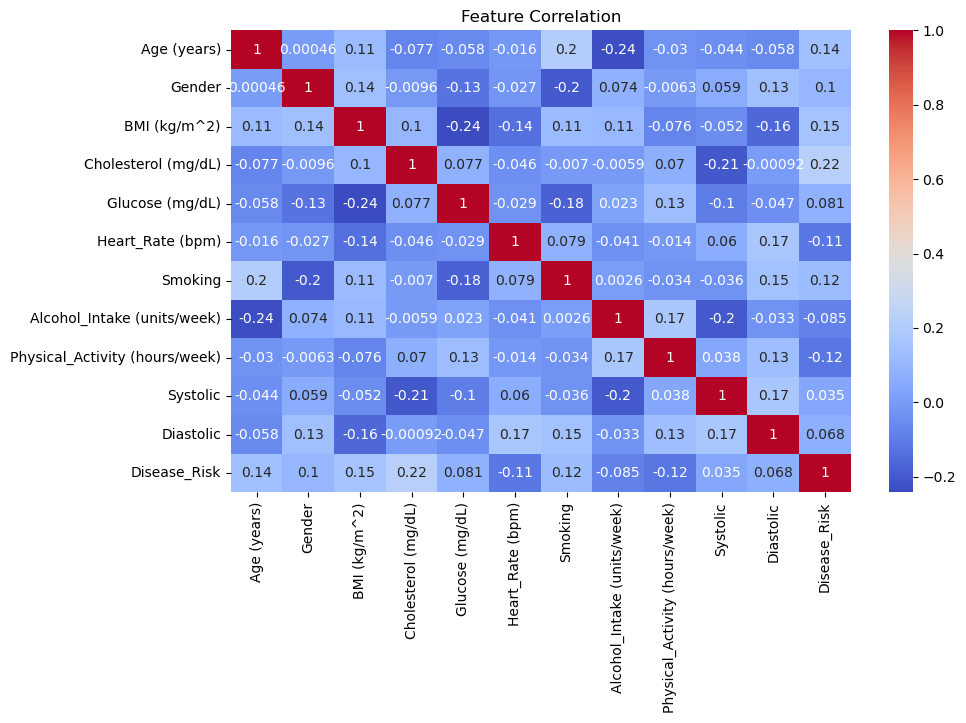

Pipeline completed successfully ✅
Train shape: (67, 44)
Test shape: (17, 44)


In [10]:
# -------------------- PHASE 1 + PHASE 2 --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- LOAD DATA ----------------
df = pd.read_csv("Improved_DataSet.csv")

print("Columns:", df.columns)
print(df.head())

# ---------------- TARGET CLEANING FIRST ----------------
if "Disease_Risk" not in df.columns:
    raise ValueError("Target column 'Disease_Risk' not found")

# Convert target to numeric
df["Disease_Risk"] = df["Disease_Risk"].astype(str).str.strip().str.lower().map({
    "low": 0,
    "medium": 0,
    "high": 1
})

# Save target separately
y = df["Disease_Risk"]

# ---------------- FEATURE CLEANING ----------------

# Split Blood Pressure
if "Blood_Pressure (mmHg)" in df.columns:
    bp = df["Blood_Pressure (mmHg)"].astype(str).str.split("/", expand=True)
    df["Systolic"] = pd.to_numeric(bp[0], errors='coerce')
    df["Diastolic"] = pd.to_numeric(bp[1], errors='coerce')
    df.drop("Blood_Pressure (mmHg)", axis=1, inplace=True)

# Clean text columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip().str.lower()

# Encode categorical
if "Gender" in df.columns:
    df["Gender"] = df["Gender"].map({"male":1, "female":0, "m":1, "f":0})

if "Smoking" in df.columns:
    df["Smoking"] = df["Smoking"].map({"yes":1, "no":0, "y":1, "n":0})

# Convert word numbers
word_to_num = {
    "zero":0, "one":1, "two":2, "three":3, "four":4,
    "five":5, "six":6, "seven":7, "eight":8, "nine":9,
    "ten":10, "twenty":20, "thirty":30, "forty":40, "fifty":50
}
df.replace(word_to_num, inplace=True)

# ---------------- NUMERIC CONVERSION ----------------
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# ---------------- FEATURES ----------------
X = df_numeric.drop("Disease_Risk", axis=1, errors='ignore')

# Remove useless columns
X = X.dropna(axis=1, how='all')
X = X.loc[:, X.nunique() > 1]

# Drop rows with NaN in features
X = X.dropna()

# Align target with X
y = y.loc[X.index]

# 🔥 CRITICAL FIX: remove NaN in target
mask = y.notna()
X = X[mask]
y = y[mask]

# ---------------- EDA ----------------
plt.figure(figsize=(10,6))
sns.heatmap(pd.concat([X, y], axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# ---------------- PHASE 2 ----------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# Remove low variance features
selector_var = VarianceThreshold()
X = selector_var.fit_transform(X)

# Select best features
k = min(8, X.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
X = selector.fit_transform(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------- DONE ----------------
print("Pipeline completed successfully ✅")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)